## Exploration du nouveau dataset "Oily, Dry and Normal Skin Types"

In [4]:
from pathlib import Path
import pandas as pd

# Chemins (ajustés à ta structure)
PROJECT_ROOT = Path("__file__").resolve().parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "skin_images" / "generated_dataset"
CLASSES = ["dry", "normal", "oily"]

# 1. Vérification de l'existence du dossier
print(f"Dossier data : {DATA_DIR}")
if not DATA_DIR.exists():
    print("Erreur : Le dossier DATA_DIR n'existe pas.")
else:
    # 2. Comptage des images par classe
    records = []
    for cls in CLASSES:
        folder = DATA_DIR / cls
        if folder.exists():
            # On cherche spécifiquement tes PNG
            images = list(folder.glob("*.png")) + list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg"))
            records.append({"class": cls, "count": len(images)})
        else:
            print(f"Dossier manquant : {folder}")

    # 3. Création du DataFrame et affichage des stats
    df_counts = pd.DataFrame(records)
    total_all = df_counts['count'].sum()

    print("\n--- Synthèse du Dataset ---")
    print(f"Total d'images : {total_all}\n")

    for index, row in df_counts.iterrows():
        pct = (row['count'] / total_all) * 100
        print(f"  {row['class'].upper():8s} — {row['count']:4d} images ({pct:.1f}%)")

    # 4. Vérification d'équilibre (Alerte si écart > 5%)
    if df_counts['count'].std() / df_counts['count'].mean() > 0.05:
        print("\n Attention : Ton dataset est légèrement déséquilibré.")
    else:
        print("\n Dataset parfaitement équilibré pour l'entraînement.")

Dossier data : /Users/ines.laguerre/Desktop/skinmatch/data/raw/skin_images/generated_dataset

--- Synthèse du Dataset ---
Total d'images : 916

  DRY      —  303 images (33.1%)
  NORMAL   —  304 images (33.2%)
  OILY     —  309 images (33.7%)

 Dataset parfaitement équilibré pour l'entraînement.


#### Conclusions

**Volumétrie globale** bien inférieure au dataset Kaggle qui disposait de 3 152 images au total, mais qui n'a pas encore subi de data augmentation contrairement à celui de Kaggle.

**Split et Data Augmentation** : contrairement au dataset Kaggle, ce dataset n'est pas encore splitté en train, val, test et n'a pas encore été augmenté.

**Balance des classes** : la distribution est  parfaitement équilibrée contrairement au dataset Kaggle, donc pas besoin cette fois-ci de compenser avec un **`WeightedRandomSampler`** dans le DataLoader ni de passer des **`class_weight`** à la CrossEntropyLoss.

### Dimensions des images

In [5]:
from PIL import Image
import pandas as pd

# Échantillonnage des dimensions sur le dataset brut (avant split)
dim_records = []

for cls in CLASSES:
    folder = DATA_DIR / cls
    # Priorité aux PNG, mais scanne tout pour être sûr
    images = list(folder.glob("*.png")) + list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg"))
    
    # Échantillon de 50 images max par classe pour l'analyse
    sample = images[:50]
    
    for img_path in sample:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                dim_records.append({
                    "class": cls,
                    "width": w,
                    "height": h,
                    "ratio": round(w/h, 2) if h != 0 else 0,
                    "mode": img.mode, # Crucial pour détecter le RGBA (transparence)
                    "filename": img_path.name
                })
        except Exception as e:
            print(f"Image corrompue ou illisible : {img_path.name} — {e}")

# Création du DataFrame d'analyse
df_dims = pd.DataFrame(dim_records)

print(f"Statistiques des dimensions (échantillon de {len(df_dims)} images au total) :")
# Affichage condensé des moyennes et écarts-types
stats = df_dims.groupby("class")[["width", "height", "ratio"]].agg(["mean", "std"]).round(1)
print(stats.to_string())

print(f"\n Modes couleur détectés : {df_dims['mode'].unique()}")

# Petit check automatique
if 'RGBA' in df_dims['mode'].unique():
    print("Attention : Présence d'images en mode RGBA. La conversion en RGB sera nécessaire.")
else:
    print("Toutes les images sont en mode standard (RGB ou L).")

Statistiques des dimensions (échantillon de 150 images au total) :
        width        height        ratio      
         mean    std   mean    std  mean   std
class                                         
dry     537.5  219.0  533.1  227.4   9.3  58.3
normal  373.4   89.4  412.1  111.7   0.9   0.2
oily    113.2   12.4  119.9   17.2   1.0   0.1

 Modes couleur détectés : <ArrowStringArray>
['RGBA']
Length: 1, dtype: str
Attention : Présence d'images en mode RGBA. La conversion en RGB sera nécessaire.


#### Conclusions

- Les images sont en RGBA : conversion en RGB impérative pour la compatibilité avec les modèles de Deep Learning
- La classe oily est anormalement petite (~113px) face aux autres (~400-500px): risque que le modèle apprenne à reconnaître la "basse résolution" plutôt que la "peau grasse"
- La classe dry présente des ratios délirants (9.3) qui indique des images très étirées ou corrompues qui seront déformées lors d'un redimensionnement classique
- Le Resizing (224x224) et le Crop sont indispensables pour supprimer ces écarts de dimensions et uniformiser les caractéristiques visuelles
- Avec seulement ~300 images par classe et des résolutions si disparates, la Data Augmentation et le Transfer Learning seront vitaux pour lutter contre le risque d'overfitting

### Analyse d'échantillons d'image

On affiche une grille de **5 images par classe** (dry, normal, oily), avec un **tirage aléatoire** (`random.seed(42)` pour la reproductibilité).

On regarde **les 3 classes côte à côte** pour pouvoir comparer directement leurs caractéristiques visuelles et identifier ce qui les distingue ou les rapproche.

**Ce qu'on cherche à évaluer :**
- Les images dry ressemblent-elles bien à de la peau sèche (mate, terne, parfois squameuse) ?
- Les images oily ont-elles bien un aspect brillant/luisant caractéristique ?
- Les images normal sont-elles vraiment "entre les deux" — et donc potentiellement ambiguës ?
- Y a-t-il des images mal cadrées, floues, ou visiblement mal labellisées ?

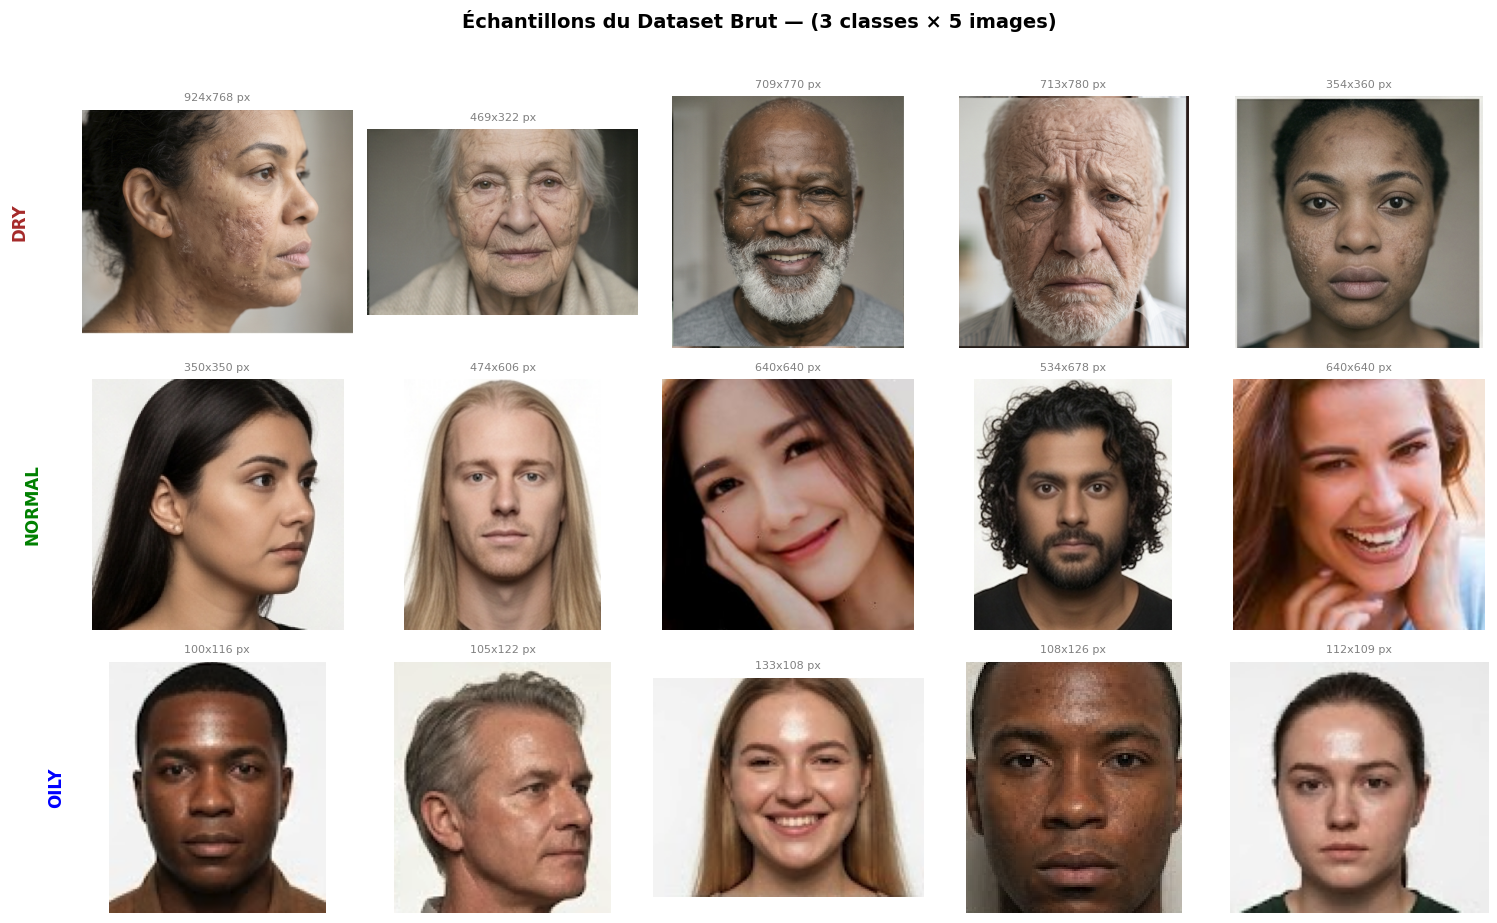

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Configuration de l'affichage
N_EXAMPLES = 5
random.seed(42)
CLASS_COLORS = {"dry": "brown", "normal": "green", "oily": "blue"}

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES, figsize=(N_EXAMPLES * 3, len(CLASSES) * 3))
fig.suptitle("Échantillons du Dataset Brut — (3 classes × 5 images)", 
             fontsize=14, fontweight='bold', y=1.02)

for row, cls in enumerate(CLASSES):
    folder = DATA_DIR / cls
    # Récupération de tous les formats possibles
    all_images = list(folder.glob("*.png")) + list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg"))
    
    if not all_images:
        print(f"Aucune image trouvée dans {folder}")
        continue
        
    sample = random.sample(all_images, min(N_EXAMPLES, len(all_images)))

    for col, img_path in enumerate(sample):
        ax = axes[row, col]
        
        # Ouverture et conversion forcée en RGB pour affichage Matplotlib propre
        img = Image.open(img_path).convert("RGB")
        
        ax.imshow(img)
        ax.axis('off')
        
        # Affichage des dimensions réelles sous chaque image
        ax.set_title(f"{img.size[0]}x{img.size[1]} px", fontsize=8, color='gray')
        
        # Label de classe sur la première colonne
        if col == 0:
            ax.text(-0.2, 0.5, cls.upper(), transform=ax.transAxes, 
                    fontsize=12, fontweight='bold', color=CLASS_COLORS.get(cls, "black"),
                    va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()

#### Observations et conclusions

**Caractéristiques visuelles attendues par classe :**
- **Dry** : manque de gras, des rougeurs, desquamations, peau fine et rugeuse, pores non visibles, rares points noirs, tâches rouges, fines rides autour de la bouche et/ou des yeux
- **Normal** : peau équilibrée, ni brillante ni terne, pas d'imperfections visibles
- **Oily** : reflets brillants visibles, notamment dans la zone T (front, nez, menton), aspect luisant, pores parfois dilatés

**Observation par classe :**
- **Dry** : le côté peau sèche est bien distinctif
- **Normal** : peaux parfaites
- **Oily** : on voit bien les reflets brillants, ainsi que la présence de pores dilatées, ba brillance est localisée (zone T).

Pas d'images qui semblent mal **labelisées**, contrairement à ce qu'on observait sur le dataset Kaggle.

**Résolution** qui semble moins bonne sur les images oily: le CNN risque d'apprendre que le "bruit de compression" ou le "flou" définit la peau grasse, plutôt que la brillance. 

Bonne **diversité** en termes de genre, age et couleur de peau (point fort pour la généralisation).

**Conclusions pour le modèle :**
- Lors du preprocessing, il faudra appliquer un léger flou gaussien (Gaussian Blur) aléatoire sur les classes dry et normal pendant la Data Augmentation pour "égaliser" la qualité perçue et forcer l'IA à se concentrer sur les pixels de brillance
- Les critères (pores dilatés, desquamations) sont des détails de micro-texture, et un modèle qui réduit trop brutalement la résolution spatiale (comme un CNN très profond avec beaucoup de MaxPooling) risque de perdre ces détails. Privilégier le Transfer Learning avec MobileNetV2 ou EfficientNet pour capturer des textures fines tout en restant légers.
- Si le modèle regarde l'ensemble de l'image (cheveux, fond, cou), le signal "brillance" sera noyé : L'Auto-Crop (MediaPipe) est ici une conclusion technique logique, en zoomant sur le visage, on augmente le ratio "pixels utiles / pixels inutiles".
- Normal est un entre-deux parfait donc la frontière entre Normal et les deux autres classes sera la plus difficile à tracer (zone de confusion). Si c'est trop souvent confondu, peut-être fournir les probabilités de sortie (Softmax) à l'utilisateur et en input du RAG (une peau peut être à 60% normal et 40% oily).

### Distribution RGB

**Pourquoi regarder la distribution RGB ?**

1. S'assurer qu'aucune classe n'est corrélée à une carnation spécifique:
- L'analyse des histogrammes RGB ou de la Luminance permet de prouver mathématiquement la bonne **diversité** de couleur de peau. 
- Si, par pur hasard de génération, la classe oily a une moyenne de pixels plus clairs que la classe dry, le modèle va associer la "peau claire" à la "peau grasse".


2. Quantifier mathématiquement les reflets spéculaires propres à la peau grasse
- La peau grasse ne change pas la couleur de la peau, elle change sa façon de réfléchir la **lumière**.
- Au lieu de regarder uniquement le RGB, convertir les images en YUV ou Lab.
- Le canal L (Lightness) ou Y (Luminance) contiendra toute l'information sur les reflets spéculaires. 
- Si l'histogramme du canal L montre des pics très élevés (proches de 255) uniquement pour la classe oily, cela prouve que les images générées sont pertinentes.

Si les distributions RGB sont quasi identiques entre les classes, cela prouve que le modèle devra se baser sur la texture (les formes) et non sur la couleur globale.

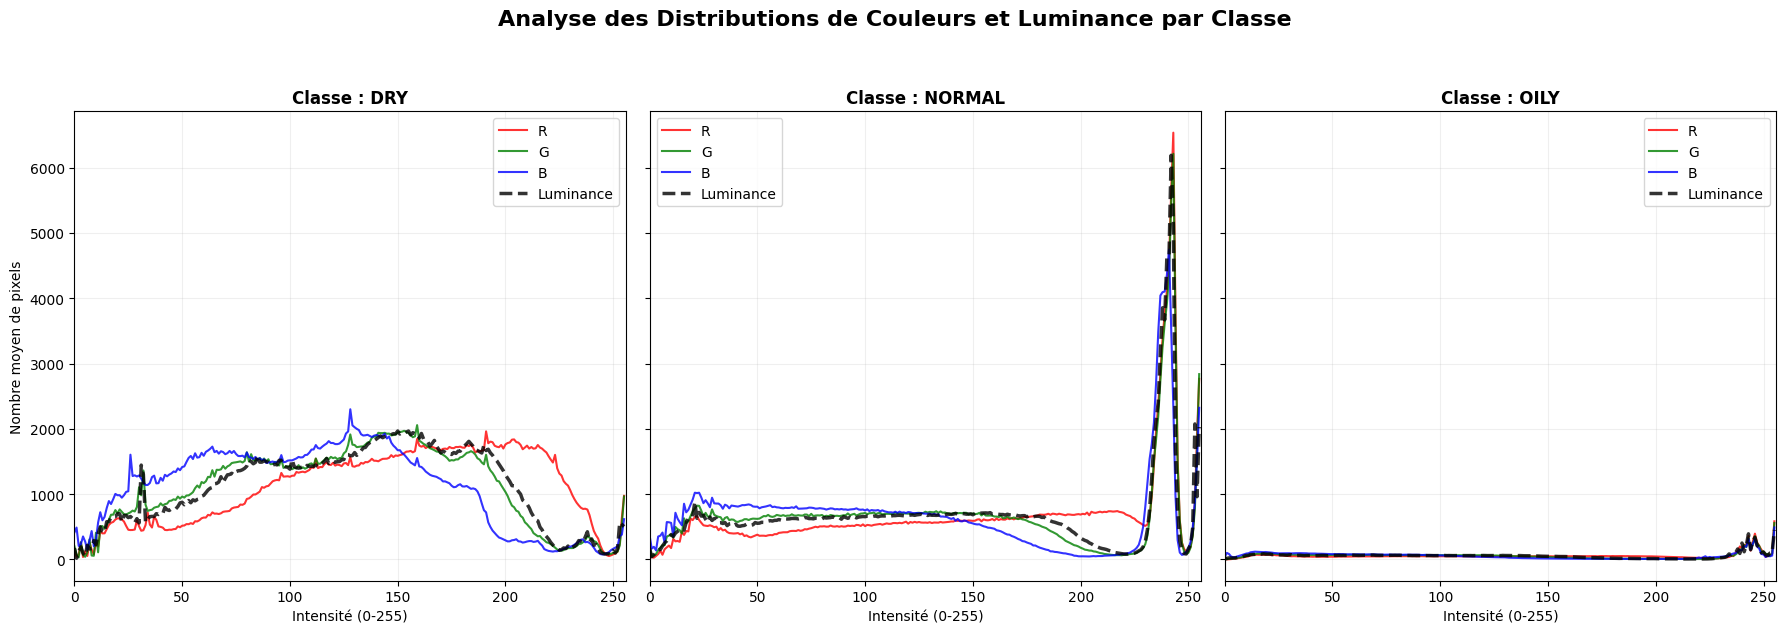

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_complete_color_analysis(data_dir, classes, n_samples=100):
    fig, axes = plt.subplots(1, len(classes), figsize=(18, 6), sharey=True)
    fig.suptitle("Analyse des Distributions de Couleurs et Luminance par Classe", 
                 fontsize=16, fontweight='bold', y=1.05)

    # Couleurs pour le plot
    line_colors = {'R': 'red', 'G': 'green', 'B': 'blue', 'L': 'black'}

    for i, cls in enumerate(classes):
        folder = Path(data_dir) / cls
        # On récupère les PNG (prioritaires) puis les autres formats
        images = list(folder.glob("*.png")) + list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg"))
        
        # Échantillonnage pour la performance
        sample_images = images[:n_samples]
        
        # Accumulateurs pour les histogrammes (256 niveaux)
        hists = {'R': [], 'G': [], 'B': [], 'L': []}

        for img_path in sample_images:
            # Lecture brute (inclut le canal alpha si présent)
            img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
            
            if img is None:
                continue

            # --- GESTION DES CANAUX ET CONVERSION ---
            if len(img.shape) == 3 and img.shape[2] == 4:
                # Cas RGBA -> conversion spécifique
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
            else:
                # Cas BGR (standard OpenCV) ou autre -> RGB
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # --- CALCUL DE LA LUMINANCE (Brillance) ---
            # Formule de luminance perçue : Y = 0.299R + 0.587G + 0.114B
            img_lum = (0.299 * img_rgb[:,:,0] + 
                       0.587 * img_rgb[:,:,1] + 
                       0.114 * img_rgb[:,:,2]).astype(np.uint8)

            # --- CALCUL DES HISTOGRAMMES ---
            for j, channel in enumerate(['R', 'G', 'B']):
                hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
                hists[channel].append(hist)
            
            # Histogramme pour la luminance
            hist_l = cv2.calcHist([img_lum], [0], None, [256], [0, 256])
            hists['L'].append(hist_l)

        # Moyennage des histogrammes pour la classe
        ax = axes[i]
        for channel in ['R', 'G', 'B', 'L']:
            if hists[channel]:
                mean_hist = np.mean(hists[channel], axis=0)
                
                # Plotting
                style = '-' if channel != 'L' else '--'
                width = 1.5 if channel != 'L' else 2.5
                ax.plot(mean_hist, color=line_colors[channel], 
                        label=channel if channel != 'L' else 'Luminance',
                        linestyle=style, linewidth=width, alpha=0.8)

        ax.set_title(f"Classe : {cls.upper()}", fontweight='bold')
        ax.set_xlim([0, 256])
        ax.set_xlabel("Intensité (0-255)")
        if i == 0: ax.set_ylabel("Nombre moyen de pixels")
        ax.legend()
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# --- EXÉCUTION ---
# CLASSES = ["dry", "normal", "oily"]
# DATA_DIR = Path(...) 
plot_complete_color_analysis(DATA_DIR, CLASSES)

#### Conclusions

**1. Le pic de saturation à 255**
- Sur NORMAL et OILY, on voit un pic sur la droite qui indique que les images générées ont beaucoup de pixels "brûlés" (blanc pur).
- Sur normal, le pic est énorme, peut-être à cause d'un fond blanc ou un éclairage studio très fort.
- Sur oily, le petit pic à 255 correspond probablement aux reflets brillants qu'on cherche.
- Conclusion : Le modèle va être très sensible aux zones blanches. 
- Solution : Auto-Crop pour enlever les fonds blancs qui polluent ces stats.

**2. La distribution des couleurs (RGB)**
- DRY : courbes très étalées, pic Rouge plus à droite que le Bleu (une peau sèche/irritée a des tons chauds/rouges)
- NORMAL : très plat jusqu'au pic final qui suggère des images très homogènes, presque trop "propres"
- OILY : distribution quasi inexistante (faible résolution), sauf pour le pic de brillance à la fin

**Conclusion**
- La présence du pic à 255 dans la classe oily valide que le signal de "luisance" est présent, mais il est noyé dans un volume de données globalement plus faible 
- Les profils colorimétriques sont trop différents donc sans une normalisation forte (type StandardScaler sur les images ou Global Average Pooling), le modèle fera du "shortcut learning" sur la luminosité globale

## Conclusion de l'EDA et décisions stratégiques

L'analyse exploratoire a révélé des caractéristiques critiques au sein du dataset généré. Bien que la qualité visuelle soit supérieure aux datasets open-source Kaggle, des disparités techniques majeures imposent des choix de preprocessing rigoureux.

### Synthèse des Observations
* **Biais de Résolution :** La classe **Oily** présente une résolution moyenne (~113px) nettement inférieure aux classes **Dry** et **Normal** (~400-500px). Sans intervention, le modèle risque de classifier les images sur la base de la qualité du grain plutôt que sur la texture cutanée.
* **Anomalies Géométriques :** La classe **Dry** contient des images aux ratios incohérents (jusqu'à 9.3), indiquant des déformations qui pourraient nuire à l'apprentissage des features morphologiques.
* **Signature de Brillance :** L'analyse de luminance confirme un pic à 255 pour les peaux grasses, validant la présence de reflets spéculaires exploitables.
* **Incompatibilité de Format :** 100% des images sont en **RGBA**, format non supporté par les architectures CNN standards.

### Décisions pour la Pipeline de Preprocessing
Pour garantir la robustesse du modèle, nous adoptons les mesures suivantes :

1.  **Standardisation du Format :** Conversion systématique **RGBA en RGB** pour stabiliser les canaux d'entrée.
2.  **Harmonisation de la Résolution :** Redimensionnement unifié en **224x224 px**. Pour la classe *Oily*, nous utiliserons une interpolation de type `CUBIC` pour limiter la perte de qualité lors de l'upscaling.
3.  **Auto-Crop & Recentrage :** Utilisation de **MediaPipe Face Detection** pour isoler le visage et éliminer les fonds (souvent responsables des pics de saturation à 255 dans la classe *Normal*).
4.  **Data Augmentation Ciblée :**
    * **Flips horizontaux** pour la diversité.
    * **Variations de luminosité/contraste** pour simuler différents éclairages sur le sébum.
    * **Ajout de flou léger (Gaussian Blur)** sur les classes de haute résolution pour neutraliser le biais de qualité face à la classe *Oily*.
5.  **Stratégie de Modélisation :** Recours au **Transfer Learning (MobileNetV2)** pour compenser la faible volumétrie (900 images) et capitaliser sur des extracteurs de textures pré-entraînés.